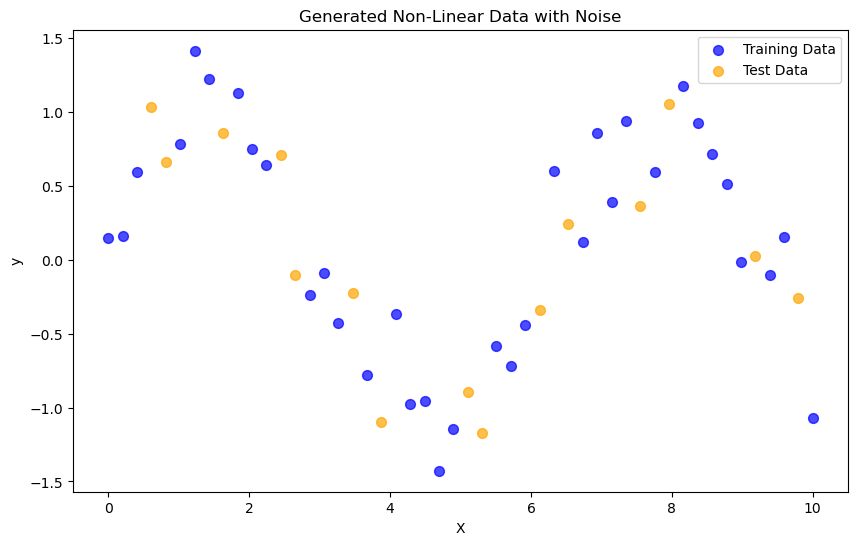

No Regularization - Train MSE: 0.0347, Test MSE: 0.1065


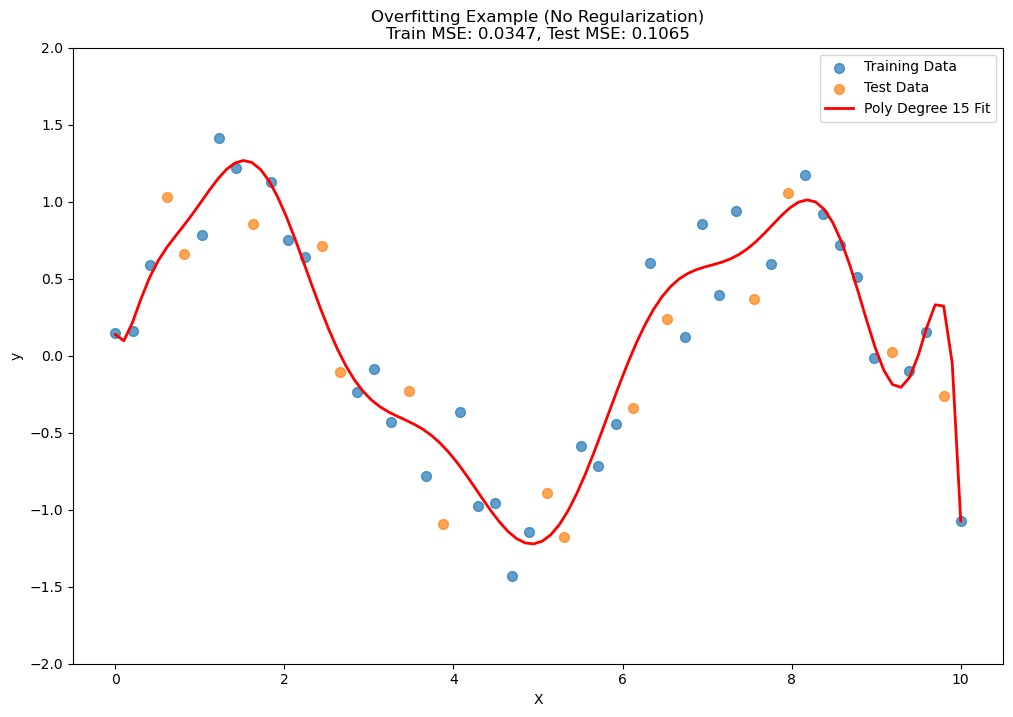

In [2]:
# %load 5-1.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, log_loss, accuracy_score

# ÉèÖÃËæ»úÖÖ×ÓÒÔÈ·±£½á¹û¿ÉÖØÏÖ
np.random.seed(42)

n_samples = 50
X = np.linspace(0, 10, n_samples)
y = np.sin(X) + np.random.normal(0, 0.3, n_samples) # ÕæÊµ¹ØÏµÊÇsin(x)¼ÓÉÏÒ»Ð©ÔëÉù

# »®·ÖÑµÁ·¼¯ºÍ²âÊÔ¼¯
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ÎªÁËÄ£ÐÍÐèÒª£¬½«X´ÓÒ»Î¬Êý×é×ª»»Îª¶þÎ¬Êý×é£¨sklearnÒªÇó£©
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

# ¿ÉÊÓ»¯Êý¾Ý
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, s=50, alpha=0.7, label='Training Data', c='blue')
plt.scatter(X_test, y_test, s=50, alpha=0.7, label='Test Data', c='orange')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Generated Non-Linear Data with Noise')
plt.show()

poly_degree = 15 # ¹ÊÒâÊ¹ÓÃºÜ¸ßµÄ¶àÏîÊ½´ÎÊý£¬¼«Ò×¹ýÄâºÏ
model_no_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=poly_degree, include_bias=False)),
    ('scaler', StandardScaler()), # ÕýÔò»¯Ç°±ê×¼»¯ÖÁ¹ØÖØÒª£¡
    ('linear', LinearRegression())
])

# ÑµÁ·Ä£ÐÍ
model_no_reg.fit(X_train, y_train)

# Ô¤²â
y_train_pred = model_no_reg.predict(X_train)
y_test_pred = model_no_reg.predict(X_test)

# ¼ÆËãMSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"No Regularization - Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")

# »æÖÆÄâºÏÇúÏß
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
y_plot_pred = model_no_reg.predict(X_plot)

plt.figure(figsize=(12, 8))
plt.scatter(X_train, y_train, s=50, alpha=0.7, label='Training Data')
plt.scatter(X_test, y_test, s=50, alpha=0.7, label='Test Data')
plt.plot(X_plot, y_plot_pred, 'r-', label=f'Poly Degree {poly_degree} Fit', linewidth=2)
plt.ylim(-2, 2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title(f'Overfitting Example (No Regularization)\nTrain MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}')
plt.show()

